In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sns.set_theme(style='darkgrid')
%matplotlib inline

## Load FD001 and FD002

In [10]:
COLS = (
    ['engine_id', 'cycle'] +
    [f'op_{i}' for i in range(1,4)] +
    [f's{i}' for i in range(1,22)]
)

train1 = pd.read_csv('../CMAPSSData/train_FD001.txt', sep=r'\s+', header=None, names=COLS)
train2 = pd.read_csv('../CMAPSSData/train_FD002.txt', sep=r'\s+', header=None, names=COLS)

print("FD001 engines:", train1['engine_id'].nunique(), "| rows:", len(train1))
print("FD002 engines:", train2['engine_id'].nunique(), "| rows:", len(train2))



FD001 engines: 100 | rows: 20631
FD002 engines: 260 | rows: 53759


## Visualize the operating condition

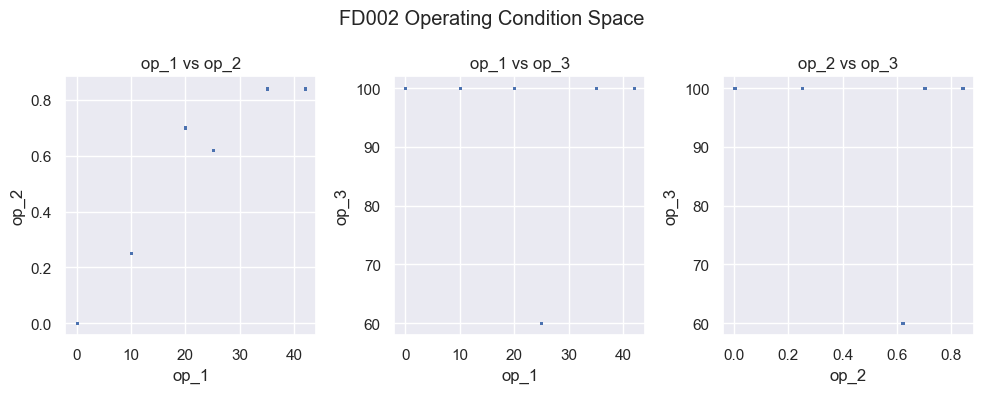

In [34]:
fig, axes = plt.subplots(1,3, figsize=(10,4))

op_pairs = [('op_1', 'op_2') , ('op_1', 'op_3'), ('op_2', 'op_3')]
for ax, (x, y) in zip(axes, op_pairs):
    ax.scatter(train2[x], train2[y], alpha=0.05, s=1)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')


plt.suptitle('FD002 Operating Condition Space')
plt.tight_layout()
plt.show()

## K-means Clustering

In [19]:
op_cols = ['op_1', 'op_2', 'op_3']
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train2['condition'] = kmeans.fit_predict(train2[op_cols])

print("Cluster sizes:")
print(train2['condition'].value_counts().sort_index())
print("\nCluster centers:")
centers = pd.DataFrame(kmeans.cluster_centers_, columns=op_cols)
print(centers.round(3))

Cluster sizes:
condition
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64

Cluster centers:
     op_1   op_2   op_3
0  42.003  0.840  100.0
1  20.003  0.701  100.0
2  25.003  0.621   60.0
3   0.002  0.000  100.0
4  10.003  0.250  100.0
5  35.003  0.841  100.0


## Visualize Cluster

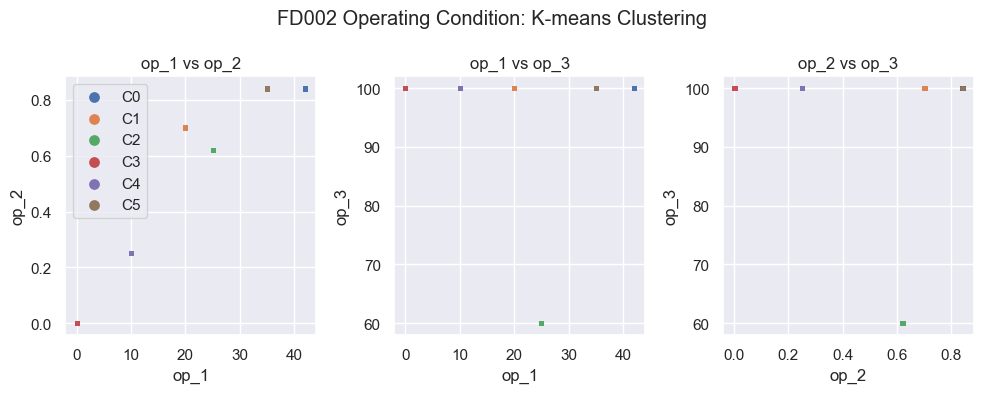

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(10,4))

op_pairs = [('op_1' , 'op_2'), ('op_1' , 'op_3'), ('op_2' , 'op_3')]
for ax, (x, y) in zip(axes, op_pairs):
    for c in range(6):
        subset = train2[train2['condition'] == c ]
        ax.scatter(subset[x], subset[y], alpha=0.3, s=5, label=f'C{c}')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

legend = axes[0].legend(markerscale=3)
for lh in legend.legend_handles:
    lh.set_alpha(1)
plt.suptitle('FD002 Operating Condition: K-means Clustering')
plt.tight_layout()
plt.show()

## Per-condition sensor distribution

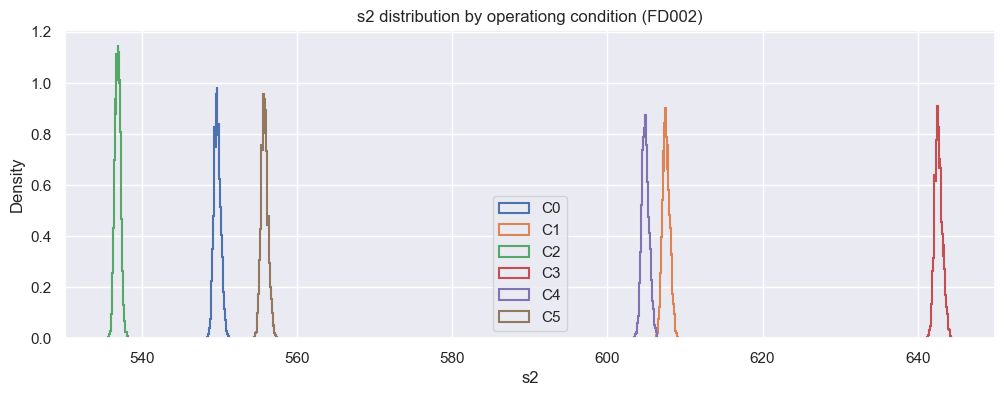

In [47]:
sensor = 's2'

fig, ax = plt.subplots(figsize=(12,4))
for c in range(6):
    subset = train2[train2['condition'] == c]
    ax.hist(subset[sensor], bins=40, density=True, label=f'C{c}',
        histtype='step', linewidth=1.5)

ax.set_title(f'{sensor} distribution by operationg condition (FD002)')
ax.set_xlabel(sensor)
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout
plt.show()

## FD001 vs FD002 Sensor distribution


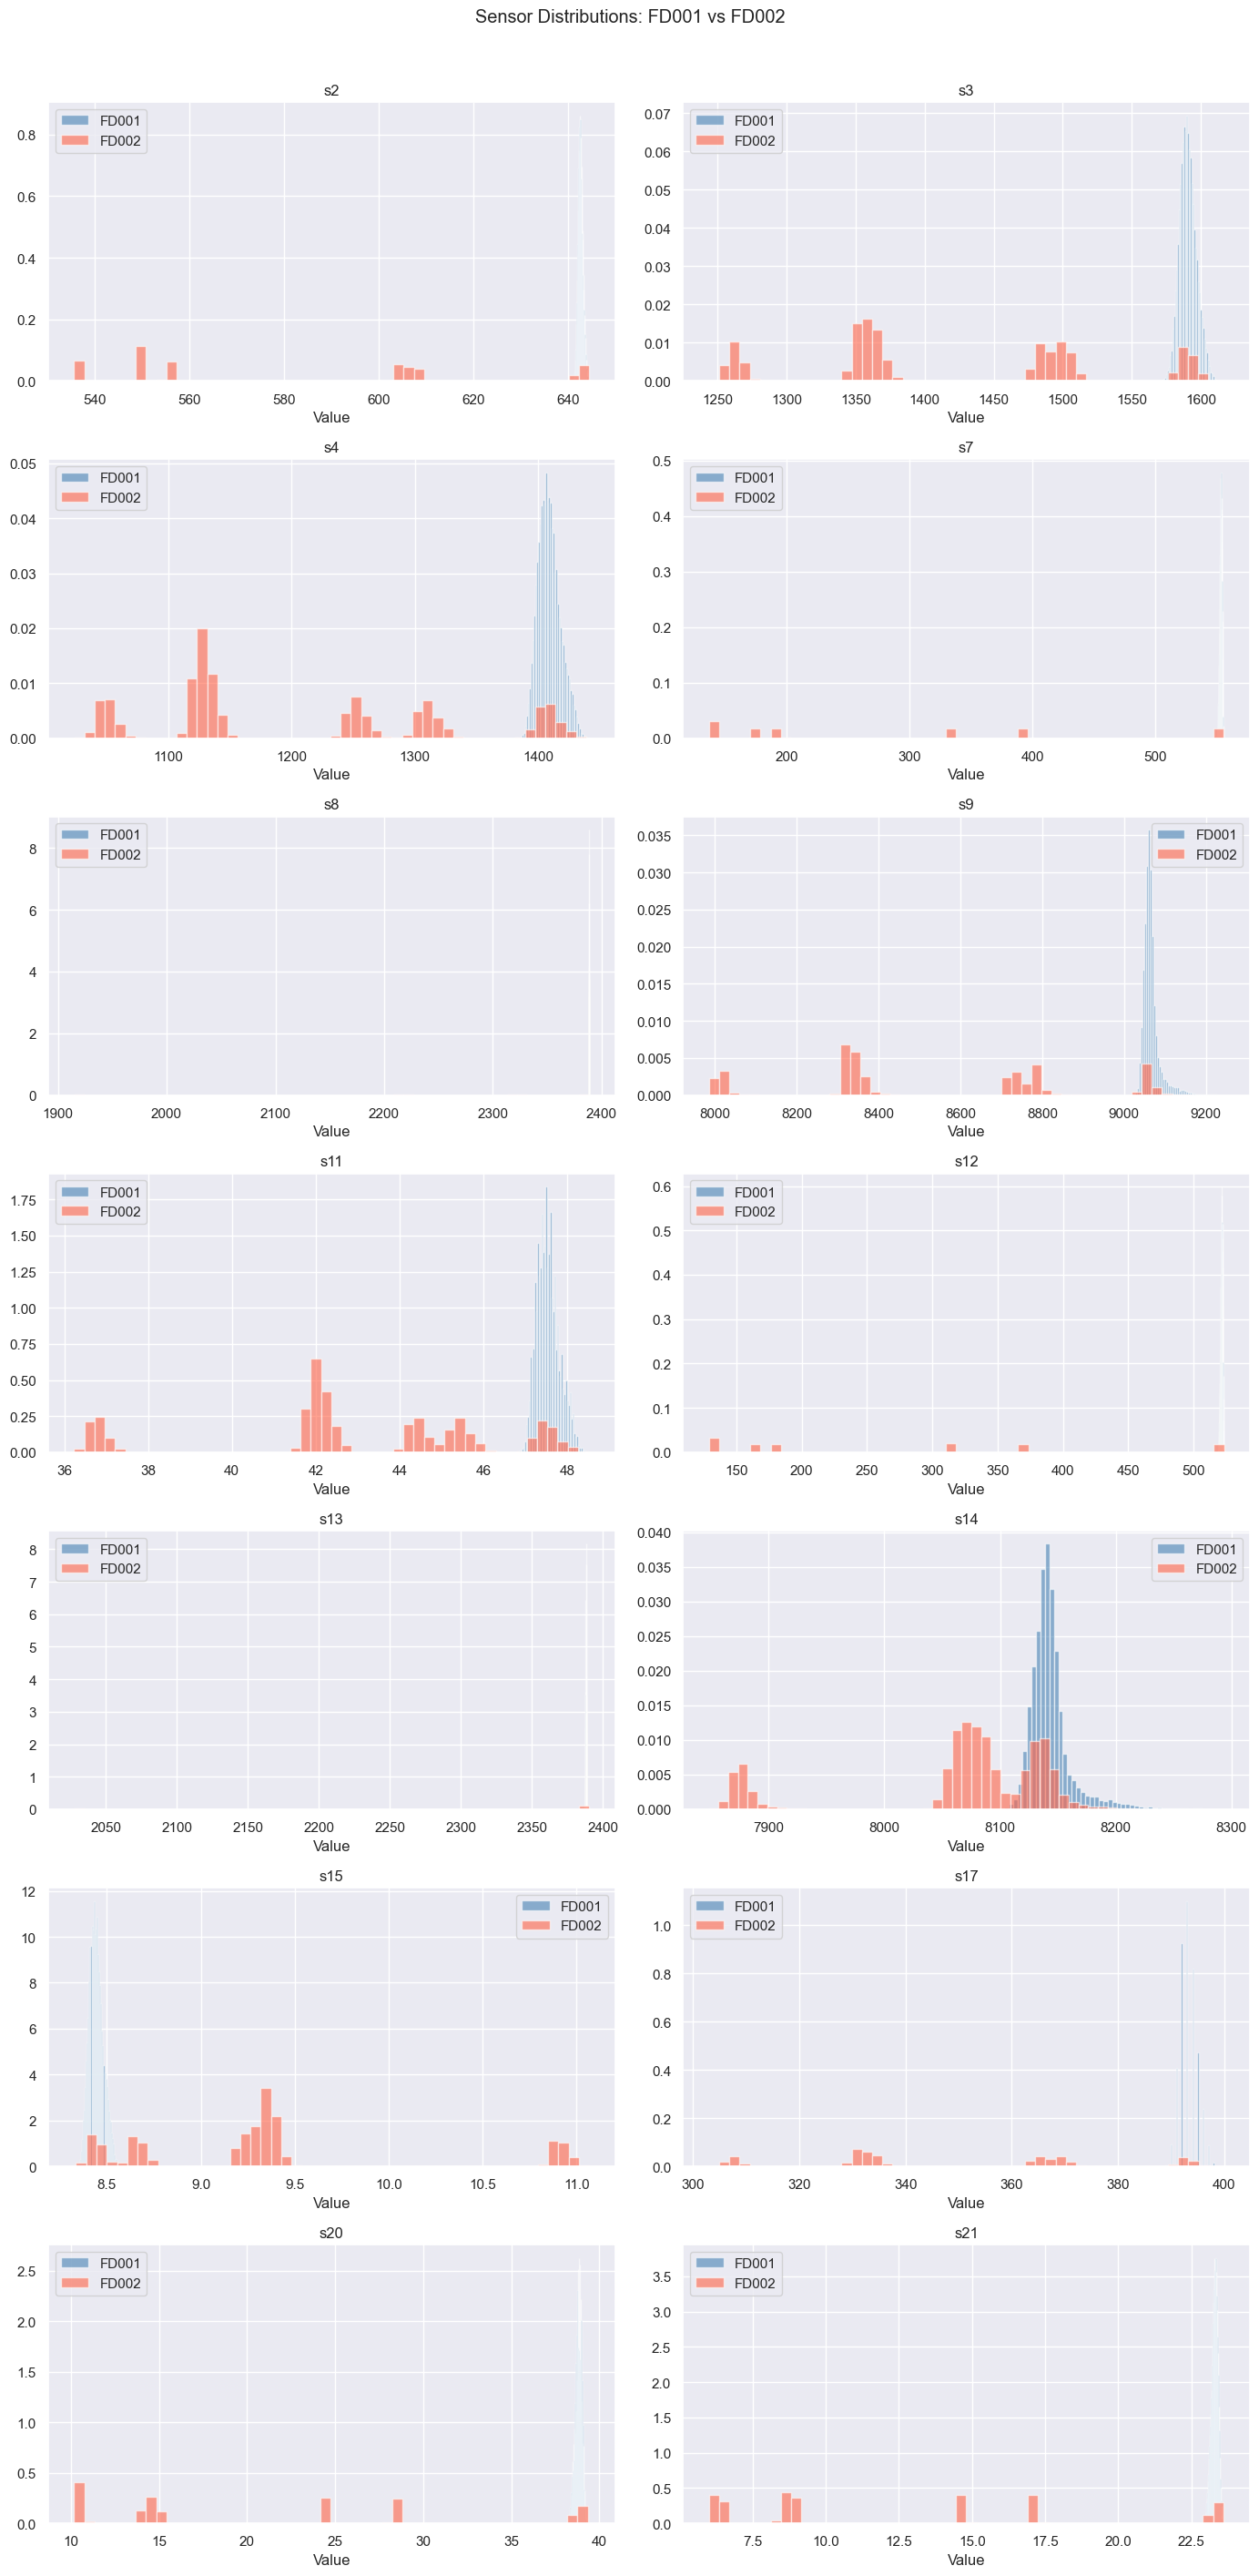

In [48]:
sensors_to_plot = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

fig, axes = plt.subplots(7, 2, figsize=(14, 28))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    axes[i].hist(train1[sensor], bins=50, alpha=0.6, density=True, label='FD001', color='steelblue')
    axes[i].hist(train2[sensor], bins=50, alpha=0.6, density=True, label='FD002', color='tomato')
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Value')
    axes[i].legend()

plt.suptitle('Sensor Distributions: FD001 vs FD002', y=1.01)
plt.tight_layout()
plt.show()